# **DATA SCIENCE CAPSTONE PROJECT 1 – PRCP-1001: Rice Leaf Disease Detection Using Convolutional Neural Networks (CNN)**


PROJECT TITLE: Rice Leaf Disease Detection Using Convolutional Neural Networks (CNN)

TEAM CODE: PTID-AIE-JUL-26-11142

PROJECT CODE: PRCP-1001

PROJECT TYPE: Data Science Capstone Project

DATASET SOURCE: DataMites Capstone Project Dataset

DATASET NAME: Rice Leaf Disease Dataset

DATASET LINK:
https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1001-RiceLeaf.zip

SUBMITTED BY:
Sameeksha

**1. IMPORT LIBRARIES**

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras import layers, optimizers

warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


**2. UPLOAD AND EXTRACT DATASET**

In [4]:
import zipfile

zip_path = "PRCP-1001-RiceLeaf.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("RiceLeaf_Dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
for root, dirs, files in os.walk("RiceLeaf_Dataset"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-" * 50)

RiceLeaf_Dataset
Folders: ['Data']
Files: []
--------------------------------------------------
RiceLeaf_Dataset/Data
Folders: []
Files: ['Bacterial leaf blight-20200814T055237Z-001.zip', 'Brown spot-20200814T055208Z-001.zip', 'Leaf smut-20200814T055530Z-001.zip']
--------------------------------------------------


In [7]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)
print("All disease folders extracted successfully!")

/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.06.04
/content/.config/configurations
/content/RiceLeaf_Dataset
/content/RiceLeaf_Dataset/Data
/content/sample_data
All disease folders extracted successfully!


In [8]:
import os

print(os.listdir("/content/RiceLeaf_Dataset/Data"))

['Bacterial leaf blight-20200814T055237Z-001.zip', 'Brown spot-20200814T055208Z-001.zip', 'Leaf smut-20200814T055530Z-001.zip']


In [10]:
import os
import zipfile

data_path = "/content/RiceLeaf_Dataset/Data"

for file in os.listdir(data_path):
    if file.endswith(".zip"):
        zip_file = os.path.join(data_path, file)
        extract_folder = os.path.join(data_path, file.replace(".zip", ""))

        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(extract_folder)

print("All disease ZIP files extracted successfully!")

All disease ZIP files extracted successfully!


In [11]:
for root, dirs, files in os.walk("/content/RiceLeaf_Dataset/Data"):
    print(root)

/content/RiceLeaf_Dataset/Data
/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001
/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001/Bacterial leaf blight
/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001
/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001/Leaf smut
/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001
/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001/Brown spot


**3.BASIC DATASET CHECKS (EDA)**


In [12]:
dataset_path = "/content/RiceLeaf_Dataset/Data"

class_folders = {
    "Bacterial Leaf Blight": "/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001/Bacterial leaf blight",
    "Brown Spot": "/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001/Brown spot",
    "Leaf Smut": "/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001/Leaf smut"
}

In [13]:
import os
for root, dirs, files in os.walk(dataset_path):
    print(root)

/content/RiceLeaf_Dataset/Data
/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001
/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001/Bacterial leaf blight
/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001
/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001/Leaf smut
/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001
/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001/Brown spot


In [14]:
print("Disease Classes:\n")
for cls in class_folders.keys():
    print(cls)

Disease Classes:

Bacterial Leaf Blight
Brown Spot
Leaf Smut


In [15]:
for cls, folder in class_folders.items():
    print(cls, ":", len(os.listdir(folder)), "images")

Bacterial Leaf Blight : 40 images
Brown Spot : 40 images
Leaf Smut : 39 images


In [16]:
from PIL import Image

for cls, folder in class_folders.items():
    image_path = os.path.join(folder, os.listdir(folder)[0])

    img = Image.open(image_path)
    print(cls, ":", img.size)

Bacterial Leaf Blight : (3081, 897)
Brown Spot : (3081, 897)
Leaf Smut : (3081, 897)


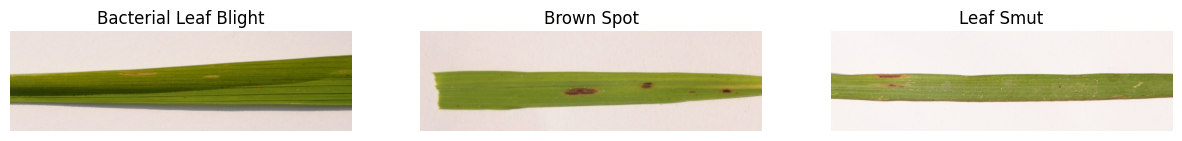

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i, (cls, folder) in enumerate(class_folders.items()):
    image_path = os.path.join(folder, os.listdir(folder)[0])

    img = Image.open(image_path)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [18]:
from PIL import Image

corrupt_images = 0

for cls, folder in class_folders.items():
    for image in os.listdir(folder):
        image_path = os.path.join(folder, image)

        try:
            img = Image.open(image_path)
            img.verify()
        except:
            corrupt_images += 1

print("Total Corrupt Images:", corrupt_images)

Total Corrupt Images: 0


**4. ORGANIZING THE DATASET FOR CNN MODEL**

In [19]:
import os
import shutil

# Source folders
source_folders = {
    "Bacterial Leaf Blight": "/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001/Bacterial leaf blight",
    "Brown Spot": "/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001/Brown spot",
    "Leaf Smut": "/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001/Leaf smut"
}

# New dataset folder
new_dataset = "/content/RiceLeaf"

os.makedirs(new_dataset, exist_ok=True)

# Copy images into new class folders
for class_name, source in source_folders.items():
    destination = os.path.join(new_dataset, class_name)
    os.makedirs(destination, exist_ok=True)

    for image in os.listdir(source):
        shutil.copy(
            os.path.join(source, image),
            os.path.join(destination, image)
        )

print("New dataset created ")

New dataset created 


In [20]:
dataset_path = "/content/RiceLeaf"

classes = []
counts = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        classes.append(folder)
        counts.append(len(os.listdir(folder_path)))

df = pd.DataFrame({
    "Class": classes,
    "Number of Images": counts
})

df

,Class,Number of Images
0,Leaf Smut,39
1,Bacterial Leaf Blight,40
2,Brown Spot,40


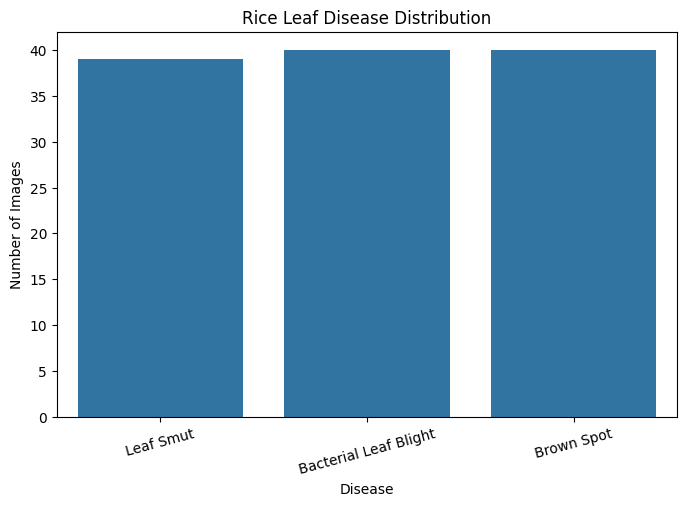

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Class", y="Number of Images")

plt.title("Rice Leaf Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

plt.show()

**5. SPLIT DATASET**

In [22]:
dataset_path = "/content/RiceLeaf"

In [23]:
!pip install split-folders

In [24]:
import splitfolders

input_folder = "/content/RiceLeaf"

splitfolders.ratio(
    input=input_folder,
    output="/content/RiceLeaf_Split",
    seed=42,
    ratio=(0.8, 0.2)
)

print("Dataset split completed successfully!")

Copying files: 119 files [00:00, 2873.64 files/s]

Dataset split completed successfully!


In [25]:
train_dir = "/content/RiceLeaf_Split/train"
validation_dir = "/content/RiceLeaf_Split/val"

In [26]:
import os

print("Training Classes:")
print(os.listdir(train_dir))

print("\nValidation Classes:")
print(os.listdir(validation_dir))

Training Classes:
['Leaf Smut', 'Bacterial Leaf Blight', 'Brown Spot']

Validation Classes:
['Leaf Smut', 'Bacterial Leaf Blight', 'Brown Spot']


In [27]:
for folder in os.listdir(train_dir):
    train_count = len(os.listdir(os.path.join(train_dir, folder)))
    val_count = len(os.listdir(os.path.join(validation_dir, folder)))

    print(f"{folder}")
    print(f"  Training Images   : {train_count}")
    print(f"  Validation Images : {val_count}\n")

Leaf Smut
  Training Images   : 31
  Validation Images : 8

Bacterial Leaf Blight
  Training Images   : 32
  Validation Images : 8

Brown Spot
  Training Images   : 32
  Validation Images : 8



**6. DATA PREPROCESSING AND DATA AUGMENTATION**

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)


# Only Normalization for Validation Data
validation_datagen = ImageDataGenerator(
    rescale=1./255
)


# Training Data Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


# Validation Data Generator
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


# Display Class Labels
print("Class Labels:")
print(train_generator.class_indices)

Found 95 images belonging to 3 classes.
Found 24 images belonging to 3 classes.
Class Labels:
{'Bacterial Leaf Blight': 0, 'Brown Spot': 1, 'Leaf Smut': 2}


In [29]:
images, labels = next(train_generator)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 3)


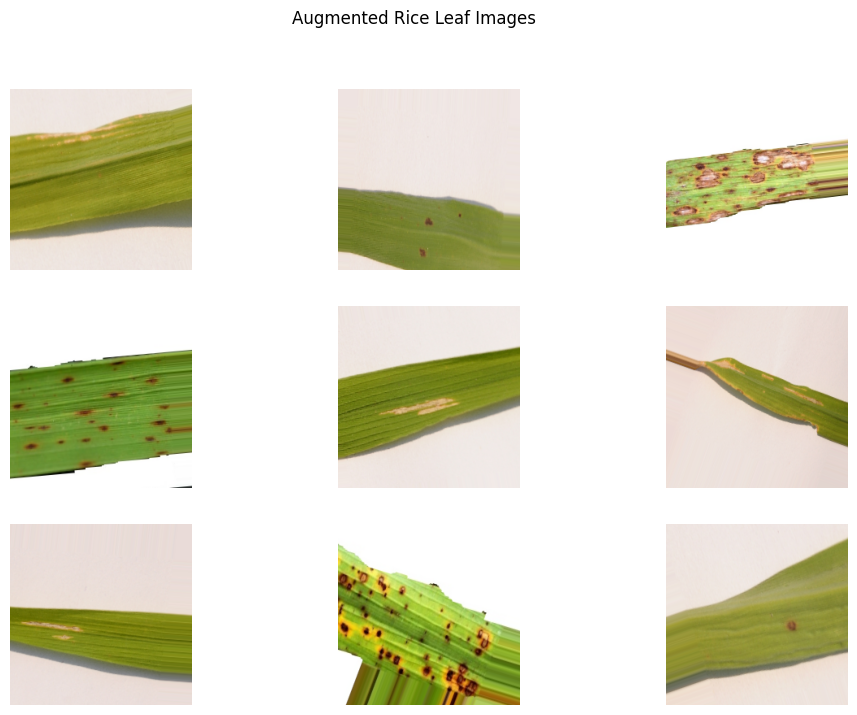

In [30]:
import matplotlib.pyplot as plt

# Get one batch of augmented images
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Augmented Rice Leaf Images")
plt.show()

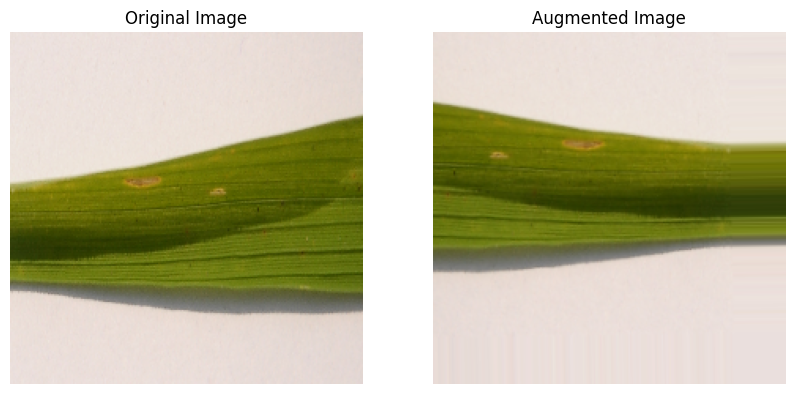

In [32]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

image_path = "/content/RiceLeaf/Bacterial Leaf Blight/" + os.listdir("/content/RiceLeaf/Bacterial Leaf Blight")[0]

img = load_img(image_path, target_size=(224,224))

img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)


plt.figure(figsize=(10,5))

# Original image
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")


# Augmented image
aug_iter = train_datagen.flow(img_array, batch_size=1)

aug_image = next(aug_iter)[0]

plt.subplot(1,2,2)
plt.imshow(aug_image)
plt.title("Augmented Image")
plt.axis("off")

plt.show()

**7. CNN MODEL**

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


model = Sequential()


# Convolution Block 1
model.add(Conv2D(
    32,
    (3,3),
    activation="relu",
    input_shape=(224,224,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))


# Convolution Block 2
model.add(Conv2D(
    64,
    (3,3),
    activation="relu"
))

model.add(MaxPooling2D(pool_size=(2,2)))


# Convolution Block 3
model.add(Conv2D(
    128,
    (3,3),
    activation="relu"
))

model.add(MaxPooling2D(pool_size=(2,2)))


# Flatten Layer
model.add(Flatten())


# Fully Connected Layer
model.add(Dense(128, activation="relu"))

model.add(Dropout(0.5))


# Output Layer
model.add(Dense(
    3,
    activation="softmax"
))


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Compile CNN Model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "best_rice_leaf_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)


history = model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.2947 - loss: 1.9507 - val_accuracy: 0.5833 - val_loss: 1.2711
Epoch 2/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.3789 - loss: 1.2455 - val_accuracy: 0.3333 - val_loss: 1.0655
Epoch 3/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4211 - loss: 1.0918 - val_accuracy: 0.3333 - val_loss: 1.0249
Epoch 4/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.3789 - loss: 1.1400 - val_accuracy: 0.6250 - val_loss: 1.0163
Epoch 5/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4000 - loss: 1.0838 - val_accuracy: 0.6250 - val_loss: 1.0222
Epoch 6/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.5263 - loss: 1.0515 - val_accuracy: 0.5000 - val_loss: 0.9875
Epoch 7/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.4737 - loss: 1.0246 - val_accuracy: 0.5833 - val_loss: 0.9424
Epoch 8/40
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.4526 - loss: 1.0191 - val_accuracy: 0.6250 - val_loss: 0.9116
Epoch 9/

In [36]:
model.save("Rice_Leaf_Disease_CNN_Model.keras")

print("Model Saved ")

Model Saved 


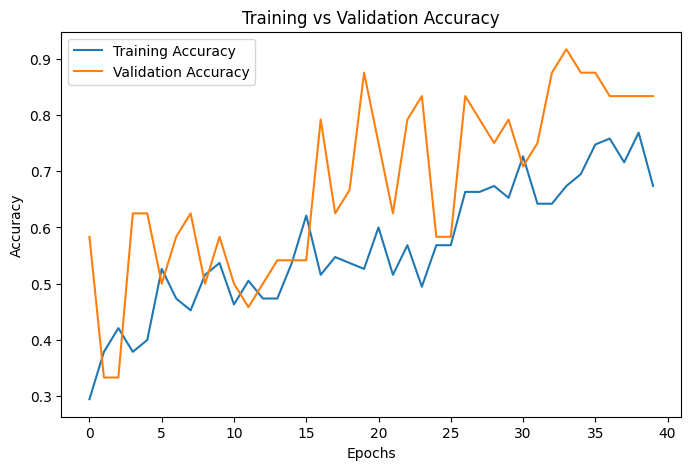

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

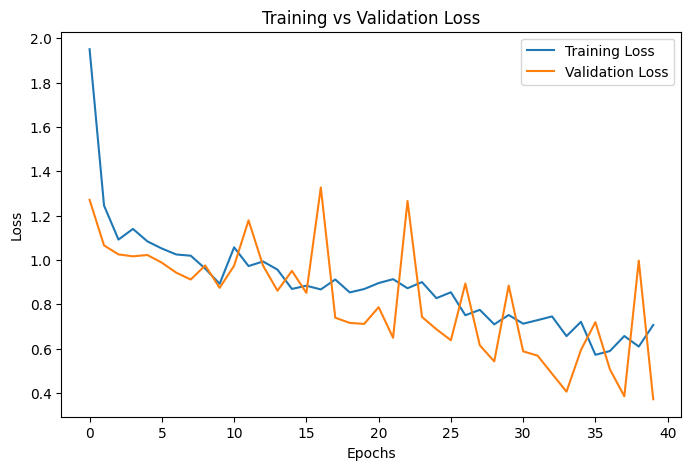

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [39]:
val_loss, val_accuracy = model.evaluate(validation_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step - accuracy: 0.8333 - loss: 0.3715
Validation Loss: 0.37154126167297363
Validation Accuracy: 0.8333333134651184


In [45]:
splitfolders.ratio(
    input="/content/RiceLeaf",
    output="/content/RiceLeaf_Split",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 119 files [00:00, 1747.08 files/s]


In [46]:
train_dir = "/content/RiceLeaf_Split/train"
validation_dir = "/content/RiceLeaf_Split/val"
test_dir = "/content/RiceLeaf_Split/test"

In [44]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Found 13 images belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.7692 - loss: 0.4326
Test Loss: 0.43255138397216797
Test Accuracy: 0.7692307829856873


In [47]:
# Save the trained CNN model

model.save("cnnmodel.hdf5")

print("Model saved successfully!")

Model saved successfully!


evalution metrics

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8333 - loss: 0.3715
Validation Loss : 0.37154126167297363
Validation Accuracy : 0.8333333134651184
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step

Classification Report

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.89      1.00      0.94         8
           Brown Spot       0.70      0.88      0.78         8
            Leaf Smut       1.00      0.62      0.77         8

             accuracy                           0.83        24
            macro avg       0.86      0.83      0.83        24
         weighted avg       0.86      0.83      0.83        24



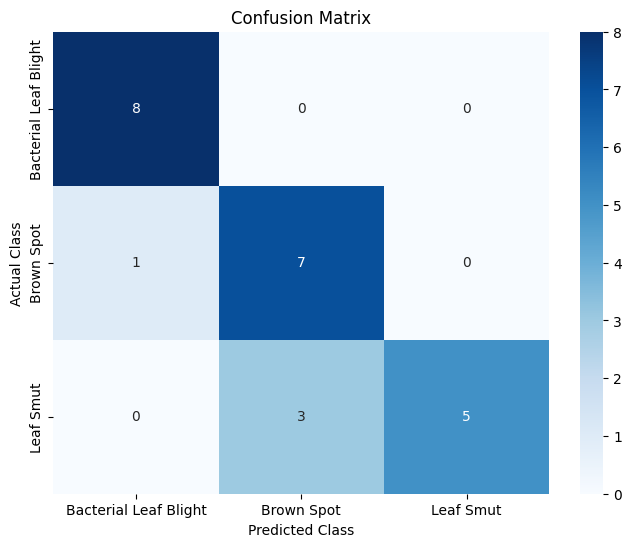

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate the Model
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)


# Predict Classes
validation_generator.reset()

y_pred = model.predict(validation_generator)

y_pred = np.argmax(y_pred, axis=1)

y_true = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())


# Classification Report
print("\nClassification Report\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

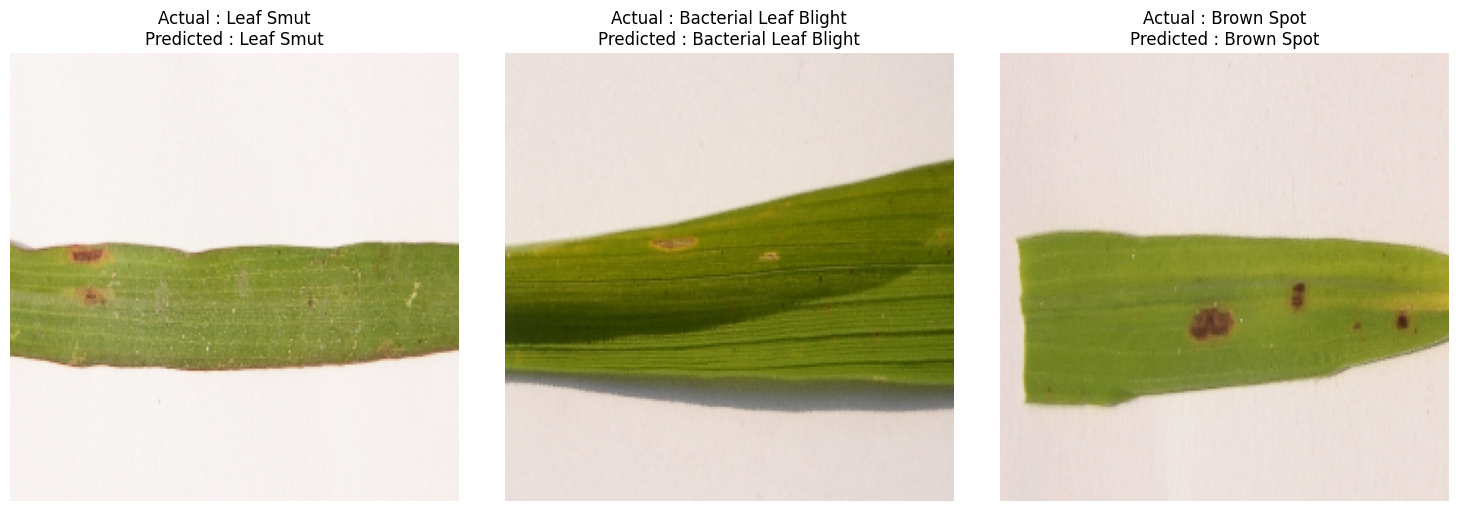

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Class folders
image_paths = [
    "/content/RiceLeaf/Leaf Smut/" + os.listdir("/content/RiceLeaf/Leaf Smut")[0],
    "/content/RiceLeaf/Bacterial Leaf Blight/" + os.listdir("/content/RiceLeaf/Bacterial Leaf Blight")[0],
    "/content/RiceLeaf/Brown Spot/" + os.listdir("/content/RiceLeaf/Brown Spot")[0]
]

class_names = ["Bacterial Leaf Blight", "Brown Spot", "Leaf Smut"]

plt.figure(figsize=(15,5))

for i, img_path in enumerate(image_paths):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    actual_class = os.path.basename(os.path.dirname(img_path))

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Actual : {actual_class}\nPredicted : {predicted_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
from google.colab import files

uploaded = files.upload()

Saving leaf2.jpg to leaf2.jpg


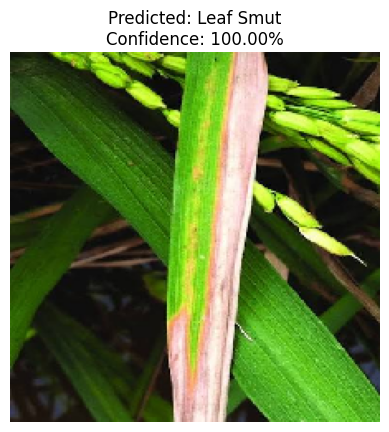

Predicted Disease : Leaf Smut
Confidence : 100.0 %


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Class Names
class_names = [
    "Bacterial Leaf Blight",
    "Brown Spot",
    "Leaf Smut"
]

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(image_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")

# Preprocess image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show prediction
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Disease :", predicted_class)
print("Confidence :", round(confidence,2), "%")